In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("car data.csv")

# Display the first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
# Dataset shape
print("Number of rows and columns:", df.shape)

# Dataset information
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Statistical summary
print("\nStatistical summary:")
df.describe()

Number of rows and columns: (301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Number of duplicate rows: 2

Statistical summary:


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [3]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

# Check unique values in categorical columns
print("\nFuel Type values:")
print(df["Fuel_Type"].unique())

print("\nSeller Type values:")
print(df["Seller_Type"].unique())

print("\nTransmission values:")
print(df["Transmission"].unique())

Shape after removing duplicates: (299, 9)

Fuel Type values:
['Petrol' 'Diesel' 'CNG']

Seller Type values:
['Dealer' 'Individual']

Transmission values:
['Manual' 'Automatic']


### Feature Engineering

Two new features are created to improve the analysis and prediction of car prices:

- **Car_Age:** Represents the age of the car based on its manufacturing year.
- **Brand:** Extracted from the 'Car_Name' column to capture brand-level differences in selling price.

In [8]:
# Feature Engineering

# Calculate the age of each car
df["Car_Age"] = df["Year"].max() - df["Year"]

# Extract the car brand from the car name
df["Brand"] = df["Car_Name"].str.split().str[0]

# Display the newly created features
df[["Car_Name", "Year", "Car_Age", "Brand"]].head(10)

,Car_Name,Year,Car_Age,Brand
0,ritz,2014,4,ritz
1,sx4,2013,5,sx4
2,ciaz,2017,1,ciaz
3,wagon r,2011,7,wagon
4,swift,2014,4,swift
5,vitara brezza,2018,0,vitara
6,ciaz,2015,3,ciaz
7,s cross,2015,3,s
8,ciaz,2016,2,ciaz
9,ciaz,2015,3,ciaz


### Distribution of Selling Prices

The distribution of selling prices is examined to understand the overall price range of the cars and identify whether the target variable is concentrated or skewed.

c:\Users\rupes\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


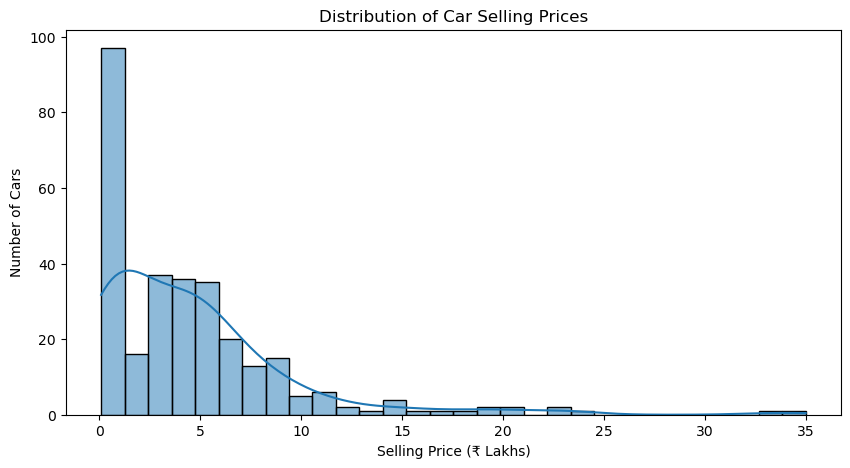

In [7]:
# Distribution of Selling Prices

plt.figure(figsize=(10, 5))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price (₹ Lakhs)")
plt.ylabel("Number of Cars")

plt.show()

#### Observation

The selling price distribution is right-skewed. Most cars have selling prices concentrated in the lower range, while a smaller number of cars have considerably higher selling prices. This indicates substantial variation in the target variable and suggests that factors such as car age, brand, fuel type, and present price may influence the selling price.

### Selling Price vs Fuel Type

A box plot is used to compare the distribution of selling prices across different fuel types and identify differences in price range and variability.

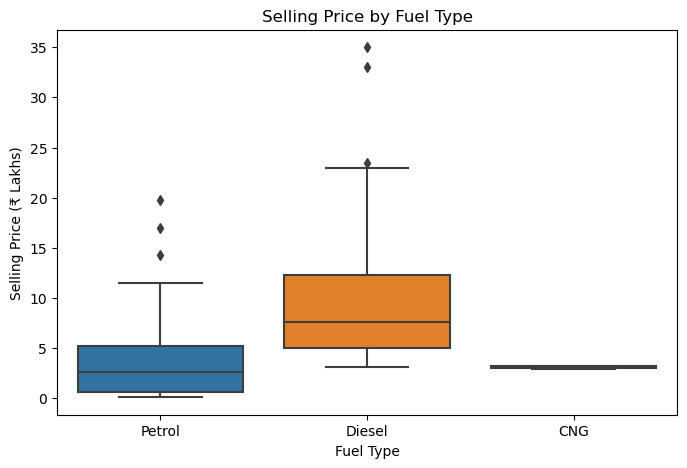

In [9]:
# Selling Price vs Fuel Type

plt.figure(figsize=(8, 5))

sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (₹ Lakhs)")

plt.show()

##### Observation

The box plot shows noticeable differences in selling-price distributions across fuel types. Diesel cars have a higher median selling price and a wider price range compared with Petrol cars. Petrol cars show a lower median price with several higher-price observations. CNG cars have a much narrower price distribution in this dataset.

### Selling Price vs Car Age

A scatter plot is used to examine the relationship between car age and selling price. This helps determine whether the selling price tends to change as the vehicle becomes older.

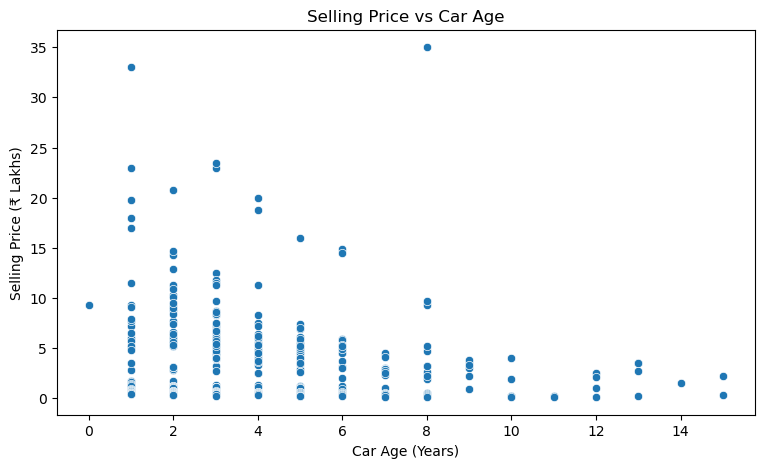

In [10]:
# Selling Price vs Car Age

plt.figure(figsize=(9, 5))

sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (₹ Lakhs)")

plt.show()

##### Observation

The scatter plot indicates a general negative relationship between car age and selling price. Newer cars tend to have higher selling prices, while older cars are mostly concentrated at lower prices. However, the variation at similar car ages suggests that other factors also influence selling price.

### Categorical Encoding

Categorical variables are converted into numerical features using One-Hot Encoding. This allows the machine learning models to process categorical information without introducing an artificial order between categories.

In [11]:
# Encode categorical variables

df_encoded = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Seller_Type", "Transmission", "Brand"],
    drop_first=True
)

# Display the encoded dataset
df_encoded.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,...,Brand_land,Brand_omni,Brand_ritz,Brand_s,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent
0,ritz,2014,3.35,5.59,27000,0,4,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,sx4,2013,4.75,9.54,43000,0,5,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2,ciaz,2017,7.25,9.85,6900,0,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,wagon r,2011,2.85,4.15,5200,0,7,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,swift,2014,4.60,6.87,42450,0,4,True,False,False,...,False,False,False,False,True,False,False,False,False,False


### Feature Correlation Heatmap

A correlation heatmap is used to examine the relationships between numerical features and the selling price. It helps identify features that may have a stronger relationship with the target variable and provides useful insight before model training.

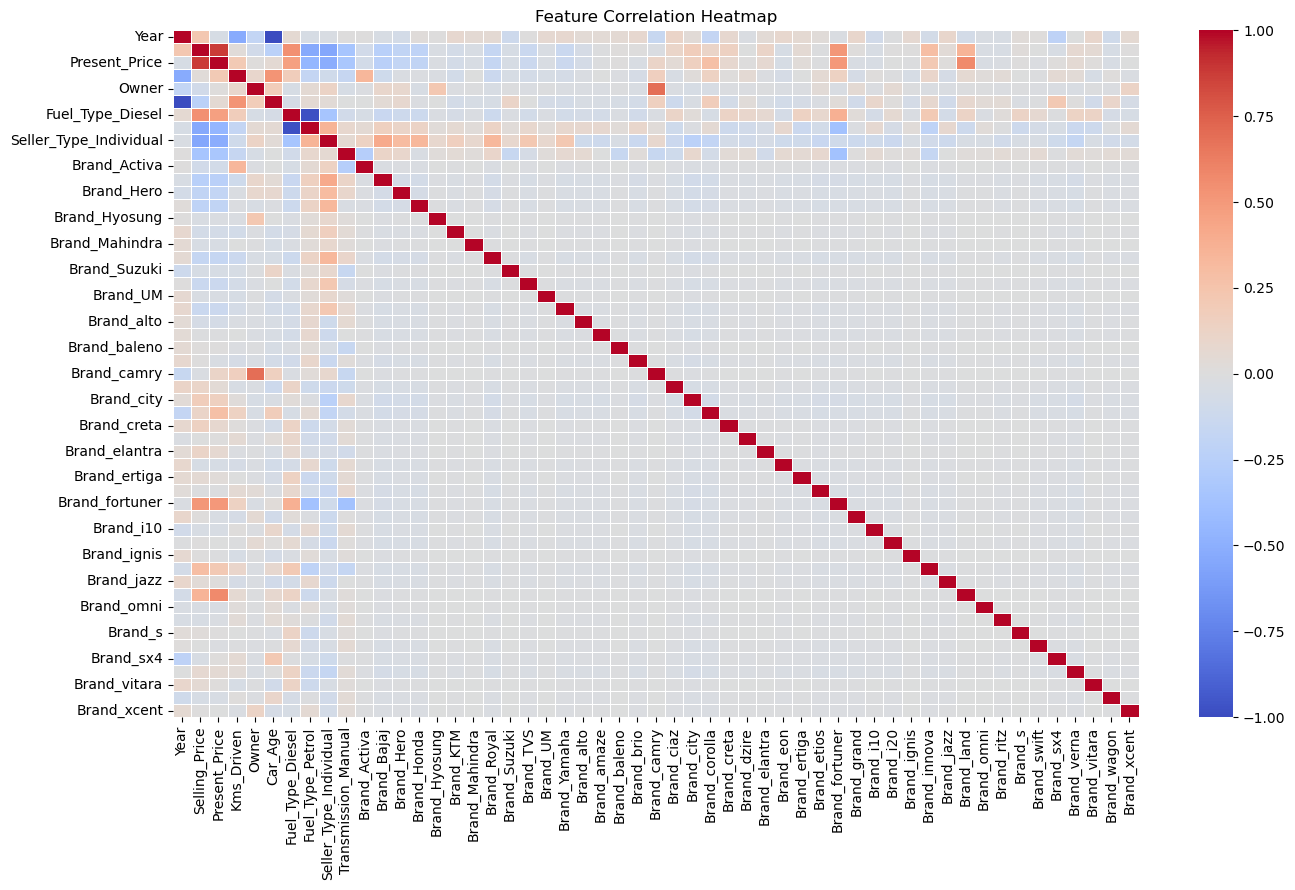

In [12]:
# Feature Correlation Heatmap

plt.figure(figsize=(14, 9))

correlation = df_encoded.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

##### Observation

The heatmap shows that `Present_Price` has a strong positive relationship with `Selling_Price`. `Year` and `Kms_Driven` show negative relationships with selling price, indicating that older and more-used cars generally tend to have lower selling prices. The encoded categorical features show varying levels of association with the target.

### Train-Test Split


In [13]:
# Prepare features and target variable

X = df_encoded.drop(["Selling_Price", "Car_Name"], axis=1)
y = df_encoded["Selling_Price"]

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 52)
Testing data: (60, 52)


### Model 1 — Linear Regression


In [14]:
# Train Linear Regression model

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Predict selling prices
linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Model 2 — Random Forest Regressor

In [15]:
# Train Random Forest Regressor model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predict selling prices
rf_predictions = rf_model.predict(X_test)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


### Model Evaluation

- **MAE:** Measures the average absolute difference between actual and predicted prices.
- **RMSE:** Measures prediction error while giving greater weight to larger errors.
- **R² Score:** Indicates how much variation in selling price is explained by the model.

In [16]:
# Evaluate both models

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression metrics
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

# Random Forest metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

# Display results
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R² Score": [linear_r2, rf_r2]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.808783,3.399321,0.551652
1,Random Forest Regressor,1.408757,3.429492,0.543658


### Model Comparison

The two regression models show different performance across the evaluation metrics. Random Forest Regressor achieves a lower MAE, indicating smaller average absolute prediction errors. However, Linear Regression achieves a slightly lower RMSE and a higher R² Score.

Therefore, the models show comparable performance, with Random Forest performing better according to MAE, while Linear Regression performs slightly better according to RMSE and R² Score. The choice of model should therefore depend on the evaluation metric considered most important for the prediction task.

### Feature Importance — Random Forest


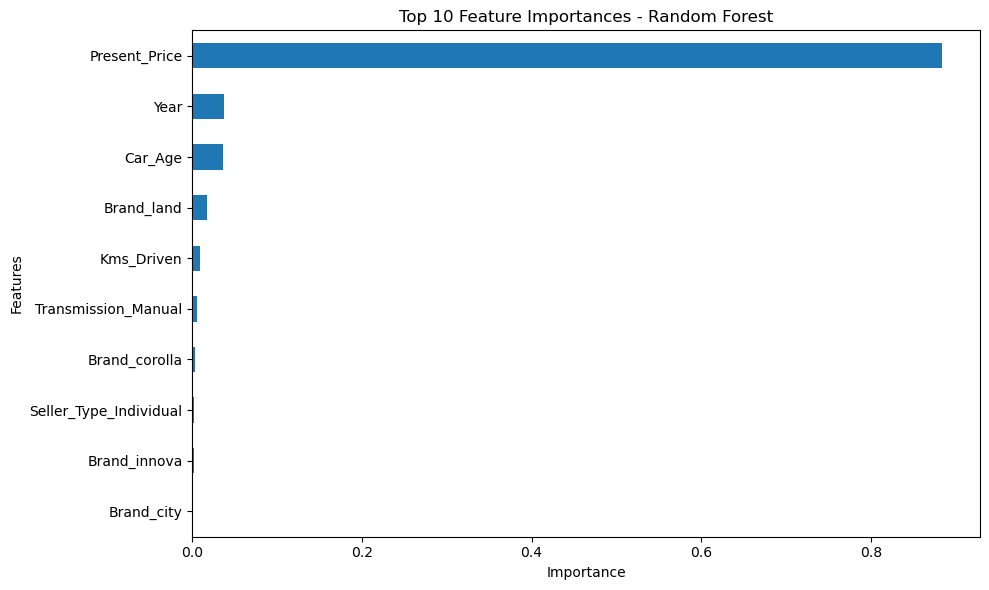

In [17]:
# Feature importance from Random Forest

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Display the top 10 important features
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

### Feature Importance Observation

The feature importance analysis shows that `Present_Price` is the most influential feature in predicting the selling price, with substantially higher importance than the other variables. `Year` and `Car_Age` are the next important features, while variables such as `Kms_Driven`, `Transmission`, and individual brand categories have comparatively lower importance in the Random Forest model.